In [1]:
import os

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config

from l3es.utils import get_real_wavenumber_grid, energy_spectrum

EPS = jnp.finfo(float).eps
config.update("jax_enable_x64", True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


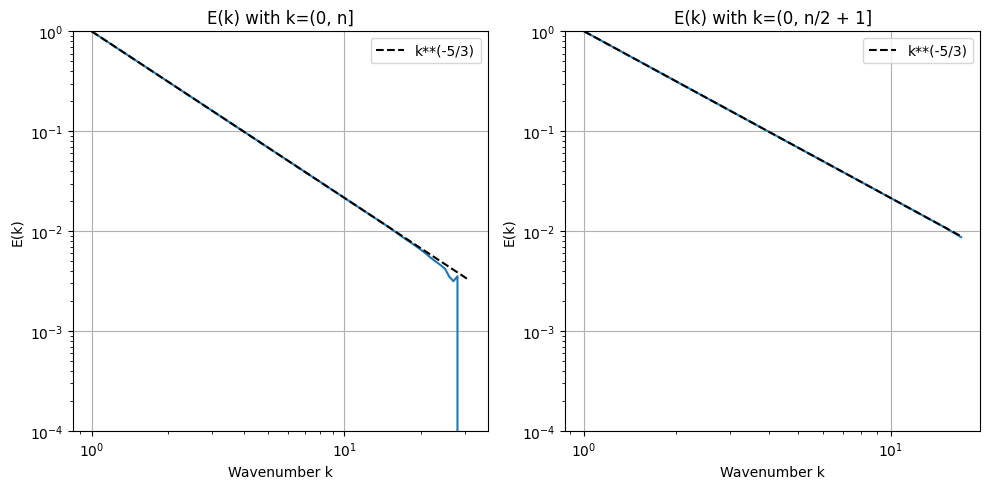

In [2]:
# my implementation
###########
def apply_conjugate_symmetry_2D(A):
    N = A.shape[0]
    Nf_ = N // 2
    A[-Nf_+1:,-Nf_+1:] = np.flip(np.conj(A[1:Nf_,1:Nf_]), axis=(0,1))
    A[1:Nf_,-Nf_+1:] = np.flip(np.conj(A[-Nf_+1:,1:Nf_]), axis=(0,1))
    A[0,-Nf_+1:] = np.flip(np.conj(A[0,1:Nf_]))
    A[-Nf_+1:,0] = np.flip(np.conj(A[1:Nf_,0]))
    return A

nx=ny=nz=32
u = np.zeros((nx//2+1, ny, nz, 3), dtype=np.complex128)  
u[:, :, :, :] = 0.
nmax = round(np.sqrt((nx**2 + ny**2 + nz**2)) / 2)   # ny -> nz

# initialize E(k)
E = np.zeros(nmax + 1) + EPS

for k in range(1, nmax+1):
    E[k] = k**(-5/3) / (4 * np.pi * k**2)

############
for k1 in range(nx // 2 + 1):  # 0-16
    i = k1
    for k2 in range(-ny // 2, ny // 2):
        j = (ny + k2) % ny  
        for k3 in range(-nz // 2, nz // 2):
            k = (nz + k3) % nz
            wk = np.sqrt(k1**2 + k2**2 + k3**2)
            wk12 = np.sqrt(k1**2 + k2**2)
            nk = round(wk)
            amp = np.sqrt(E[nk])
            phi1, phi2, phi3 = 2*np.pi * np.random.random(size=3)  # 0.948142290  # np.random.random()  # uniform in [0, 2pi)
            ai = amp * (np.cos(phi1) + np.sin(phi1) * 1j) * np.cos(phi3)
            bi = amp * (np.cos(phi2) + np.sin(phi2) * 1j) * np.sin(phi3)
            if wk != 0:
                if wk12 != 0.:
                    u[i, j, k, 0] = (ai * wk * k2 + bi * k1 * k3) / (wk * wk12)
                    u[i, j, k, 1] = (bi * k2 * k3 - ai * wk * k1) / (wk * wk12)
                else:
                    u[i, j, k, 0] = ai
                    u[i, j, k, 1] = bi
                u[i, j, k, 2] = -bi * wk12 / wk
            else:
                u[i, j, k, 0] = 0.
                u[i, j, k, 1] = 0.
                u[i, j, k, 2] = 0.
############

for ii in range(3):
    u[0,:,:,ii] = apply_conjugate_symmetry_2D(u[0,:,:,ii])
 
ur = np.fft.irfftn(u.transpose(3,0,1,2), axes=(-1,-2,-3), norm="forward")

ek = energy_spectrum(ur)
k = np.arange(1, len(ek))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(k, (ek[1:]))
axs[0].plot(k, k**(-5/3), '--', c='k', label="k**(-5/3)")
axs[0].set_ylabel("E(k)")
axs[0].set_xlabel("Wavenumber k")
axs[0].legend()
axs[0].grid()
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_ylim(1e-4, 1e0)
axs[0].set_title("E(k) with k=(0, n]")

axs[1].plot(k[:17], (ek[1:18]))
axs[1].plot(k[:17], k[:17]**(-5/3), '--', c='k', label="k**(-5/3)")
axs[1].set_ylabel("E(k)")
axs[1].set_xlabel("Wavenumber k")
axs[1].legend()
axs[1].grid()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(1e-4, 1e0)
axs[1].set_title("E(k) with k=(0, n/2 + 1]")
fig.tight_layout()

(3, 17, 32, 32) (3, 32, 32, 32)


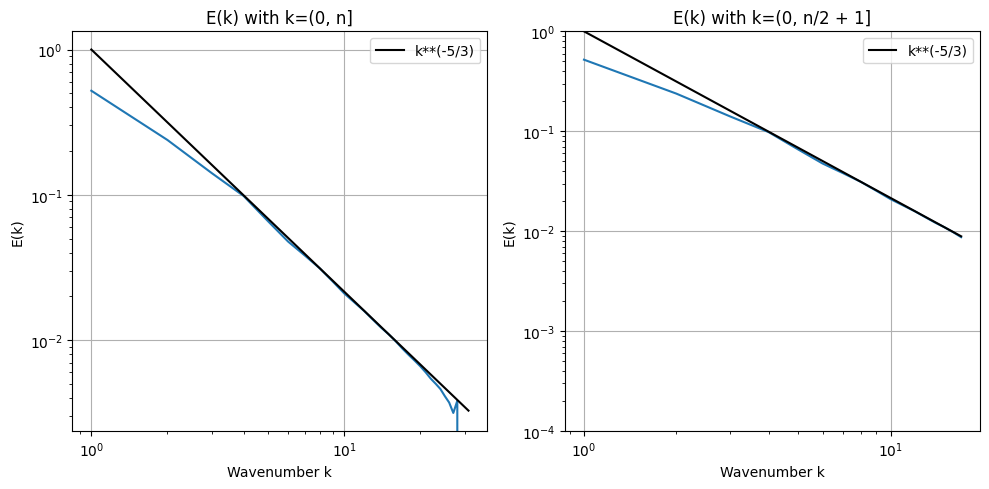

In [3]:
# Rogallo from jax-fluids

def apply_conjugate_symmetry_2D(A):
    N = A.shape[0]
    Nf_ = N // 2
    A[-Nf_+1:,-Nf_+1:] = np.flip(np.conj(A[1:Nf_,1:Nf_]), axis=(0,1))
    A[1:Nf_,-Nf_+1:] = np.flip(np.conj(A[-Nf_+1:,1:Nf_]), axis=(0,1))
    A[0,-Nf_+1:] = np.flip(np.conj(A[0,1:Nf_]))
    A[-Nf_+1:,0] = np.flip(np.conj(A[1:Nf_,0]))
    return A


N=32

# initialize wavenumber grid
k_field, k_ = get_real_wavenumber_grid(N, dim=3)

# calculate wavenumber vector norms
k = np.linalg.norm(k_field, axis=0)
k_12 = np.linalg.norm(k_field[:2, :, :, :], axis=0)

# dummy values to avoid division by zero
k[0,0,0] = EPS 
k_12 = np.where(k_12 == 0, EPS, k_12)

# split wavenumber vector in each dimension for better readability
k1 = k_field[0, :, :, :]
k2 = k_field[1, :, :, :]
k3 = k_field[2, :, :, :]

# prescribed kolmogorov energy spectrum
Ek = k**(-5/3)

# calculate pre factors
amp = np.sqrt(Ek / (4 * np.pi * k * k))
phi = 2 * np.pi * np.random.uniform(size=k_field.shape)
alpha = amp * np.exp(1j * phi[0]) * np.cos(phi[2])
beta = amp * np.exp(1j * phi[1]) * np.sin(phi[2])

# calculate velocity components in spectral space
ux_hat = (alpha * k * k2 + beta * k1 * k3) / (k * k_12)
ux_hat = np.where(k_12 == EPS, alpha, ux_hat)
uy_hat = (-alpha * k * k1 + beta * k2 * k3) / (k * k_12)
uy_hat = np.where(k_12 == EPS, k3 * beta / k, uy_hat)
uz_hat = -(beta * k_12) / (k)
uz_hat = np.where(k_12 == EPS, 0, uz_hat)

# build 3d array
u_hat = np.array([ux_hat, uy_hat, uz_hat])
u_hat = np.where(k == EPS, 0 , u_hat)

# TODO: check physical meaning -> cause it worsens results
# u_hat[:,-1,:,:] = 0.0
# u_hat[:,:,nx//2,:] = 0.0
# u_hat[:,:,:,nx//2] = 0.0

# TODO: check physical meaning
for ii in range(3):
    u_hat[ii,0] = apply_conjugate_symmetry_2D(u_hat[ii,0])
 
u = np.fft.irfftn(u_hat, axes=(-1,-2,-3), norm="forward")
print(u_hat.shape, u.shape)  # (3, 17, 32, 32) (3, 32, 32, 32)
# compute reference energy spectrum
# ek = energy_spectrum_physical(u) # JAX-FLUIDS version
ek = energy_spectrum(u) # new implementation for ek calculation (3,32,32,32)
k = np.arange(1, len(ek))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(k, (ek[1:]))
axs[0].plot(k, k**(-5/3), c='k', label="k**(-5/3)")
axs[0].set_ylabel("E(k)")
axs[0].set_xlabel("Wavenumber k")
axs[0].legend()
axs[0].grid()
axs[0].set_xscale('log')
axs[0].set_yscale('log')
# axs[0].set_ylim(1e-4, 1e0)
axs[0].set_title("E(k) with k=(0, n]")

axs[1].plot(k[:17], (ek[1:18]))
axs[1].plot(k[:17], k[:17]**(-5/3), c='k', label="k**(-5/3)")
axs[1].set_ylabel("E(k)")
axs[1].set_xlabel("Wavenumber k")
axs[1].legend()
axs[1].grid()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_ylim(1e-4, 1e0)
axs[1].set_title("E(k) with k=(0, n/2 + 1]")
fig.tight_layout()